In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import torchvision.datasets as datasets
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
from torch.optim.lr_scheduler import StepLR
from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter
from torch.utils.data import Dataset
from typing import Dict, Tuple
from tqdm import tqdm
import numpy as np
import time
import os
import random
from tabulate import tabulate
import h5py

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

%matplotlib inline

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")



Torch version: 2.7.0+cu126
CUDA available: True
CUDA version: 12.6
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090


In [23]:
def fullwg(wg):
    waveguide_tensor = torch.tensor(wg, dtype=torch.float32)
    if waveguide_tensor.ndim == 3:
        waveguide_tensor = waveguide_tensor.squeeze()
    # Mirror over x-axis (vertical flip) to get bottom-right
    bottom_right = torch.flip(waveguide_tensor, dims=[0])

    # Stack top and bottom vertically to get right half
    right_half = torch.cat([waveguide_tensor, bottom_right], dim=0)  # shape [32, 16]

    # Mirror over y-axis (horizontal flip) to get left half
    left_half = torch.flip(right_half, dims=[1])  # shape [32, 16]

    # Concatenate left and right to get full waveguide
    full_waveguide = torch.cat([left_half, right_half], dim=1)  # shape [32, 32]

    # Plot the result
    plt.imshow(full_waveguide.numpy(), cmap='viridis')
    plt.title("Full Reconstructed Waveguide")
    plt.axis('off')
    # plt.colorbar()
    plt.show()
    return full_waveguide.numpy()

import torch
import matplotlib.pyplot as plt

def fullwg(wg, x_vals=None, y1_vals=None, y2_vals=None, l1=None, l2=None):
    waveguide_tensor = torch.tensor(wg, dtype=torch.float32)
    if waveguide_tensor.ndim == 3:
        waveguide_tensor = waveguide_tensor.squeeze()

    # Mirror over x-axis (vertical flip) to get bottom-right
    bottom_right = torch.flip(waveguide_tensor, dims=[0])

    # Stack top and bottom vertically to get right half
    right_half = torch.cat([waveguide_tensor, bottom_right], dim=0)  # shape [32, 16]

    # Mirror over y-axis (horizontal flip) to get left half
    left_half = torch.flip(right_half, dims=[1])  # shape [32, 16]

    # Concatenate left and right to get full waveguide
    full_waveguide = torch.cat([left_half, right_half], dim=1)  # shape [32, 32]

    # Set up subplots: 1 row, 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    # Plot the waveguide
    axs[0].imshow(full_waveguide.numpy(), cmap='viridis')
    axs[0].set_title("Full Waveguide")
    axs[0].axis('off')

    # Plot first line graph (if provided)
    if x_vals is not None and y1_vals is not None:
        axs[1].plot(x_vals, y1_vals, 'r')
        axs[1].set_title(l1[0])
        axs[1].set_xlabel(l1[1])
        axs[1].set_ylabel(l1[2])
        axs[1].grid(True)

    # Plot second line graph (if provided)
    if x_vals is not None and y2_vals is not None:
        axs[2].plot(x_vals, y2_vals, 'b')
        axs[2].set_title(l2[0])
        axs[2].set_xlabel(l2[1])
        axs[2].set_ylabel(l2[2])
        axs[2].grid(True)

    plt.tight_layout()
    plt.show()

    return full_waveguide.numpy()

def fullwg_multi(wg_list, x_vals=None, modes_list=None, weights_list=None, l1=None, l2=None):
    """
    Visualizes 100 full waveguides (mirrored to 64x64) in a 10x10 grid, along with
    overlaid mode and weight curves.

    Parameters:
    - wg_list: list of 100 waveguides (each [32, 32] or [1, 32, 32])
    - x_vals: shared x-axis values
    - modes_list: list of 100 mode curves
    - weights_list: list of 100 weight curves
    - l1: (title, xlabel, ylabel) for mode plot
    - l2: (title, xlabel, ylabel) for weight plot

    Returns:
    - full_waveguides: numpy array [100, 64, 64]
    """
    assert len(wg_list) == 100, "Expected 100 waveguides"

    full_waveguides = []

    for wg in wg_list:
        waveguide_tensor = torch.tensor(wg, dtype=torch.float32)
        if waveguide_tensor.ndim == 3:
            waveguide_tensor = waveguide_tensor.squeeze()  # [32, 32]

        # Mirror over x-axis (vertical flip) → bottom half
        bottom = torch.flip(waveguide_tensor, dims=[0])  # [32, 32]

        # Stack vertically → [64, 32]
        vertical = torch.cat([waveguide_tensor, bottom], dim=0)

        # Mirror over y-axis (horizontal flip)
        left = torch.flip(vertical, dims=[1])  # [64, 32]

        # Stack horizontally → [64, 64]
        full_wg = torch.cat([left, vertical], dim=1)

        full_waveguides.append(full_wg.numpy())

    full_waveguides = np.stack(full_waveguides, axis=0)  # [100, 64, 64]

    # Create a grid of 10x10 waveguides
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    grid_img = np.zeros((64 * 10, 64 * 10))
    for idx, full_wg in enumerate(full_waveguides):
        row = idx // 10
        col = idx % 10
        grid_img[row*64:(row+1)*64, col*64:(col+1)*64] = full_wg

    axs[0].imshow(grid_img, cmap='viridis')
    axs[0].set_title("100 Full Waveguides (10×10 Grid)")
    axs[0].axis('off')

    # Mode curves
    if x_vals is not None and modes_list is not None:
        for mode in modes_list:
            axs[1].plot(x_vals, mode, linewidth=3)
        if l1:
            axs[1].set_title(l1[0])
            axs[1].set_xlabel(l1[1])
            axs[1].set_ylabel(l1[2])
        axs[1].grid(True)
        axs[1].set_ylim([0,4.0])

    # Weight curves
    if x_vals is not None and weights_list is not None:
        for weight in weights_list:
            axs[2].plot(x_vals, weight, linewidth=3)
        if l2:
            axs[2].set_title(l2[0])
            axs[2].set_xlabel(l2[1])
            axs[2].set_ylabel(l2[2])
        axs[2].grid(True)
        axs[2].set_ylim([0, 110])

    plt.tight_layout()
    plt.show()

    return full_waveguides




In [3]:
import matplotlib.pyplot as plt
import torch
import numpy as np

class CombinedModeWeightNet(nn.Module):
    def __init__(self, mode_model, weight_model):
        super().__init__()
        self.mode_model = mode_model
        self.weight_model = weight_model

    def forward(self, x_img, x_cond):
        mode   = self.mode_model(x_img, x_cond)   # [B, 1]
        weight = self.weight_model(x_img, x_cond) # [B, 1]
        return torch.cat((mode, weight), dim=1)   # [B, 2]

def plot_generated_vs_true(cond, generated, title=''):
    cond = cond.squeeze().cpu().numpy()       # [8]
    generated = generated.squeeze().cpu().numpy()  # [8]

    indices = np.arange(8)

    plt.figure(figsize=(10, 5))
    plt.plot(indices, cond, 'ro-', label='True Condition')
    plt.plot(indices, generated, 'bo-', label='Generated')
    plt.xticks(indices)
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title(f"Generated vs True Condition Vector {title}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_modes_and_weights(cond, generated, title=''):
    """
    Plot modes (indices 0–3) and weights (indices 4–7) on two separate axes.

    Args
    ----
    cond       : tensor of shape [1, 8]  (ground-truth)
    generated  : tensor of shape [1, 8]  (model prediction)
    """
    cond      = cond.squeeze().cpu().numpy()       # -> [8]
    generated = generated.squeeze().cpu().numpy()  # -> [8]

    modes_idx    = np.arange(4)          # 0,1,2,3
    weights_idx  = np.arange(4, 8)       # 4,5,6,7

    fig, (ax_modes, ax_weights) = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    # ── Left axis: modes ──────────────────────────────────────────
    ax_modes.plot(modes_idx, cond[:4],      'ro-', label='True')
    ax_modes.plot(modes_idx, generated[:4], 'bo-', label='Generated')
    ax_modes.set_xticks(modes_idx)
    ax_modes.set_xticklabels([f'Mode {i}' for i in modes_idx])
    ax_modes.set_xlabel("Modes")
    ax_modes.set_ylabel("Value")
    ax_modes.set_title(f"Modes 0–3 {title}")
    ax_modes.grid(True)
    ax_modes.legend()

    # ── Right axis: weights ──────────────────────────────────────
    ax_weights.plot(weights_idx, cond[4:],      'ro-', label='True')
    ax_weights.plot(weights_idx, generated[4:], 'bo-', label='Generated')
    ax_weights.set_xticks(weights_idx)
    ax_weights.set_xticklabels([f'Weight {i-4}' for i in weights_idx])
    ax_weights.set_xlabel("Weights")
    ax_weights.set_title(f"Weights 0–3 {title}")
    ax_weights.grid(True)
    ax_weights.legend()

    plt.tight_layout()
    plt.show()

In [4]:
import importlib
import only_mode_only_weight_v3
importlib.reload(only_mode_only_weight_v3)

<module 'only_mode_only_weight_v3' from '/home/omiqran/metamaterials_urop/only_mode_only_weight_v3.py'>

In [5]:
 # Load data
BATCH_SIZE = 512
filename = r"train_test_split.h5"

def quarter(pattern):
    return pattern[:32, :32]  # downsample to 32x32

# Custom Dataset class
class NeffDataset(Dataset):
    def __init__(self, patterns, params, targetm, targetw):
        self.patterns = torch.FloatTensor(patterns)
        self.params = torch.FloatTensor(params)
        self.targetm = torch.FloatTensor(targetm)
        self.targetw = torch.FloatTensor(targetw)
    
    def __len__(self):
        return len(self.patterns)
    
    def __getitem__(self, idx):
        return self.patterns[idx], self.params[idx], self.targetm[idx], self.targetw[idx]
    
def load_data(filename):
    """Load and process data from HDF5 file"""
    with h5py.File(filename, "r") as f:
        neff_train = np.array(f['neff_train'])
        weight_train = np.array(f['weight_train'])
        params_train = np.array(f['params_train'])
        pattern_train = np.array(f['pattern_train'])  # shape [N, 64, 64]
        
        neff_test = np.array(f['neff_test'])
        weight_test = np.array(f['weight_test'])
        params_test = np.array(f['params_test'])
        pattern_test = np.array(f['pattern_test'])  # shape [M, 64, 64]
    
    # Apply quarter() to every pattern (vectorized alternative)
    pattern_train_quartered = pattern_train[:, :32, :32]  # shape [N, 32, 32]
    pattern_test_quartered  = pattern_test[:, :32, :32]   # shape [M, 32, 32]

    # Reshape for downstream use if needed
    xs  = pattern_train_quartered[:, np.newaxis, :, :]
    xs1 = pattern_test_quartered[:,  np.newaxis, :, :]

    x1s  = params_train
    x1s1 = params_test
    ysm   = neff_train[:, 0:1]
    ys1m  = neff_test[:, 0:1]
    ysw   = weight_train[:, 0:1]
    ys1w  = weight_test[:, 0:1]
    
    return xs, x1s, ysm, ysw, xs1, x1s1, ys1m, ys1w
    

def create_dataloaders(xs, x1s, ysm, ysw, xs1, x1s1, ys1m, ys1w, batch_size=256):
    """Create training and test dataloaders with Windows-compatible settings"""
    train_dataset = NeffDataset(xs, x1s, ysm, ysw)
    test_dataset = NeffDataset(xs1, x1s1, ys1m, ys1w)
    
    # Use single process for Windows compatibility
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=0,  # Use 0 for Windows compatibility
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=0,  # Use 0 for Windows compatibility
        pin_memory=True
    )
    
    return train_loader, test_loader


try:
    xs, x1s, ysm, ysw, xs1, x1s1, ys1m, ys1w = load_data(filename)
    print(f"Training data shape: {xs.shape}")
    print(f"Training params shape: {x1s.shape}")
    print(f"Training targets shape: {ysm.shape}")
    print(f"Test data shape: {xs1.shape}")
    print(f"Test params shape: {x1s1.shape}")
    print(f"Test targets shape: {ys1m.shape}")
except FileNotFoundError:
    print(f"Data file not found: {filename}")
    print("Please update the filename path")
    exit()

# Create dataloaders
train_loader, test_loader = create_dataloaders(xs, x1s, ysm, ysw, xs1, x1s1, ys1m, ys1w, batch_size=BATCH_SIZE)
# print(f"Number of training batches: {len(train_loader)}")
# print(f"Number of test batches: {len(test_loader)}")

Training data shape: (1113998, 1, 32, 32)
Training params shape: (1113998, 4)
Training targets shape: (1113998, 1)
Test data shape: (477427, 1, 32, 32)
Test params shape: (477427, 4)
Test targets shape: (477427, 1)


In [6]:
from only_mode_only_weight_v3 import No_normal_modewieght_net

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mode0_model = No_normal_modewieght_net().to(device)
weight0_model = No_normal_modewieght_net().to(device)

mode0_model.load_state_dict(torch.load('models/only_first_mode_no_normalization_with_less_dropout.pth', map_location=torch.device(device)))
weight0_model.load_state_dict(torch.load('models/only_first_weight_no_normalization_with_less_dropout_100.pth', map_location=torch.device(device)))


model = CombinedModeWeightNet(mode0_model, weight0_model).to(device)

model.eval()

CombinedModeWeightNet(
  (mode_model): No_normal_modewieght_net(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn3): GroupNorm(8, 256, eps=1e-05, affine=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv4): Conv2d(260, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn4): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn5): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn6): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv7): Conv2d(256, 256, kernel_size=(3, 3),

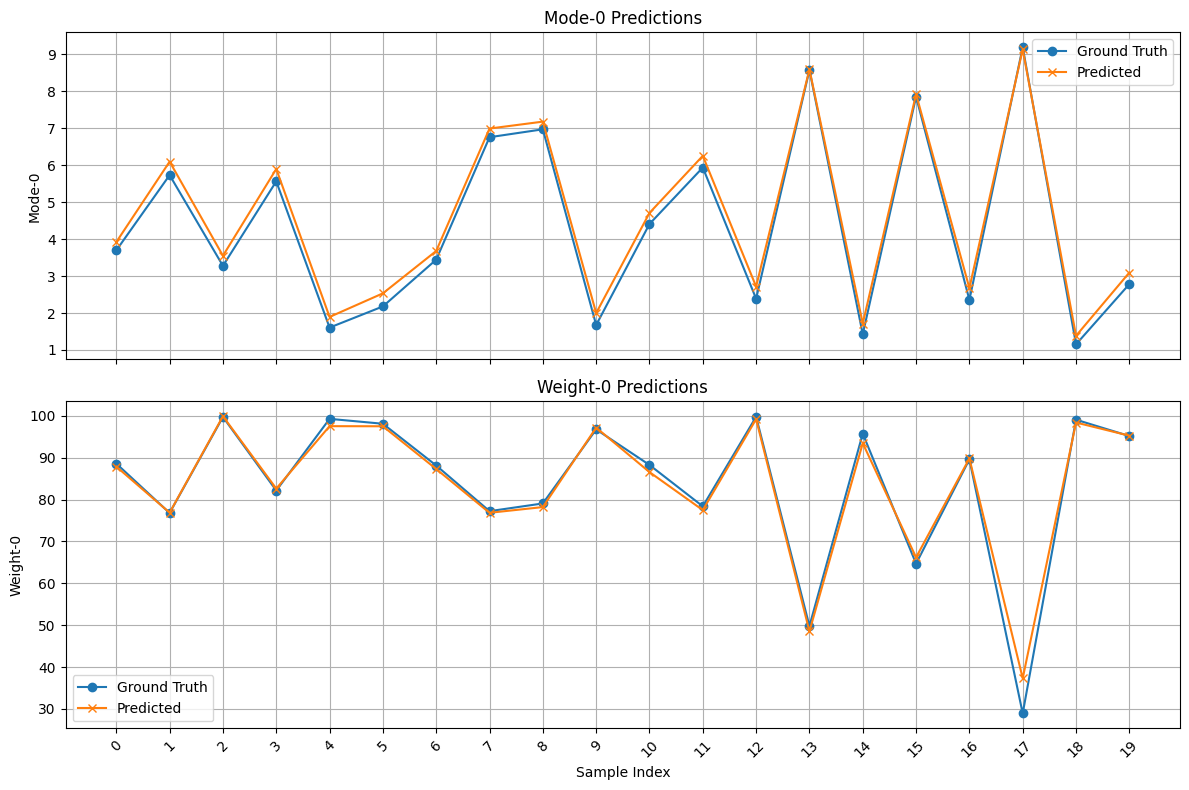

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random

def evaluate_and_plot_single_model(model, device, test_loader, n_samples=20):
    model.eval()

    dataset = test_loader.dataset
    indices = random.sample(range(len(dataset)), n_samples)

    true_modes, true_weights = [], []
    pred_modes, pred_weights = [], []

    with torch.no_grad():
        for idx in indices:
            wg, params, mode_target, weight_target = dataset[idx]

            # Move inputs to device
            wg_tensor     = wg.unsqueeze(0).to(device)       # [1, 1, 32, 32]
            params_tensor = params.unsqueeze(0).to(device)   # [1, 4]

            # Forward pass
            output = model(wg_tensor, params_tensor)         # [1, 2]
            mode_pred, weight_pred = output[0]               # Scalars

            # Store ground truth and predictions
            true_modes.append(mode_target.item())
            true_weights.append(weight_target.item())
            pred_modes.append(mode_pred.item())
            pred_weights.append(weight_pred.item())

    # ---- Plotting ----
    x = np.arange(n_samples)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(x, true_modes, label='Ground Truth', marker='o')
    ax1.plot(x, pred_modes, label='Predicted', marker='x')
    ax1.set_ylabel("Mode-0")
    ax1.set_title("Mode-0 Predictions")
    ax1.grid(True)
    ax1.legend()

    ax2.plot(x, true_weights, label='Ground Truth', marker='o')
    ax2.plot(x, pred_weights, label='Predicted', marker='x')
    ax2.set_ylabel("Weight-0")
    ax2.set_title("Weight-0 Predictions")
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(i) for i in x], rotation=45)
    ax2.set_xlabel("Sample Index")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    
evaluate_and_plot_single_model(model, device, test_loader)

/tmp/ipykernel_135651/3932754285.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wg_tensor = torch.tensor(wg, dtype=torch.float32)


Model output: tensor([[ 7.3815, 57.3284]])
Ground Truth: Mode0 = 7.2103, Weight0 = 56.2007
Model Pred:   Mode0 = 7.3815, Weight0 = 57.3284


/tmp/ipykernel_135651/2012514728.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  waveguide_tensor = torch.tensor(wg, dtype=torch.float32)


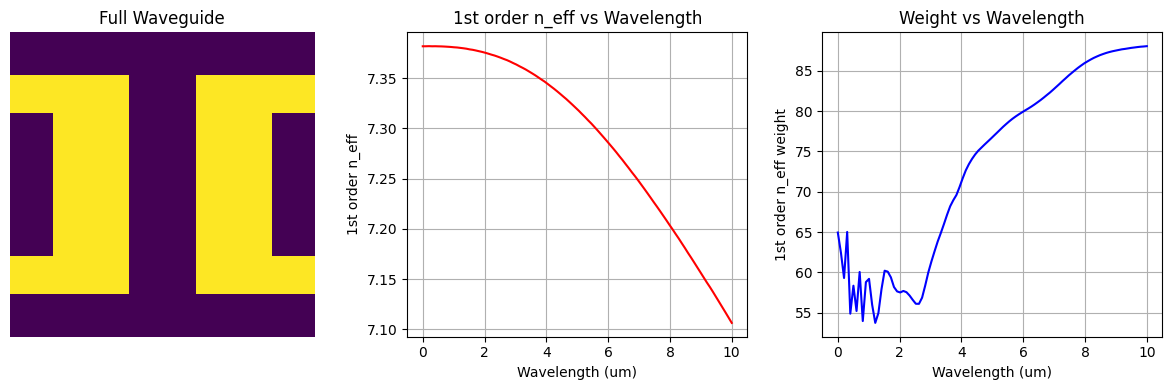

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

dataset = test_loader.dataset
wavelengths = np.linspace(0, 10, 100)
idx = random.randrange(len(dataset))

# Unpack data sample
wg, params, m_truth, w_truth = dataset[idx]

# Prepare waveguide input
wg_tensor = torch.tensor(wg, dtype=torch.float32)
if wg_tensor.ndim == 2:
    wg_tensor = wg_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, 32, 32]
elif wg_tensor.ndim == 3:
    wg_tensor = wg_tensor.unsqueeze(0)               # [1, 1, 32, 32]
wg_tensor = wg_tensor.to(device)

# Static portion of params
const_tail = params[1:].unsqueeze(0).to(device)  # [1, 3]

# Store predictions
mode0_list = []
weight0_list = []
wavelength_list = []

# Check single prediction for reference
model.eval()
pt = params.unsqueeze(0).to(device)              # [1, 4]
with torch.no_grad():
    pred = model(wg_tensor, pt)  # [1, 2]

print("Model output:", pred.cpu())
print(f"Ground Truth: Mode0 = {m_truth.item():.4f}, Weight0 = {w_truth.item():.4f}")
print(f"Model Pred:   Mode0 = {pred[0,0].item():.4f}, Weight0 = {pred[0,1].item():.4f}")

# Sweep over wavelengths
with torch.no_grad():
    for lam in wavelengths:
        lam_tensor = torch.tensor([[lam]], dtype=torch.float32).to(device)  # [1,1]
        params_tensor = torch.cat([lam_tensor, const_tail], dim=1)          # [1, 4]

        pred = model(wg_tensor, params_tensor)  # [1,2]
        mode0_list.append(pred[0, 0].item())    # directly predicted n_eff
        weight0_list.append(pred[0, 1].item())  # directly predicted weight
        wavelength_list.append(lam)

# Convert to arrays
wavelengths = np.array(wavelength_list)
neff = np.array(mode0_list)
weights = np.array(weight0_list)

# Label configs
lm0 = ['1st order n_eff vs Wavelength', 'Wavelength (um)', '1st order n_eff']
lw0 = ["Weight vs Wavelength", "Wavelength (um)", "1st order n_eff weight"]

# Plotting utility
full_wg = fullwg(wg, wavelengths, mode0_list, weight0_list, lm0, lw0)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def evaluate_100_samples(test_loader, model, device, fullwg_multi):
        

    wavelengths = np.linspace(0, 10, 100)

    all_modes = []
    all_weights = []
    selected_wg = []

    model.eval()
    dataset = test_loader.dataset

    count = 0  # Number of qualifying samples processed

    for i in range(len(dataset)):
        if count >= 100:
            break  # Stop after 100 valid samples

        # Unpack sample
        wg, params, mode_target, weight_target = dataset[i]

        if weight_target.item() <= 60:
            continue  # Skip if weight too low

        # Keep sample
        selected_wg.append(wg)

        # Format waveguide tensor
        wg_tensor = torch.tensor(wg, dtype=torch.float32)
        if wg_tensor.ndim == 2:
            wg_tensor = wg_tensor.unsqueeze(0).unsqueeze(0)
        elif wg_tensor.ndim == 3:
            wg_tensor = wg_tensor.unsqueeze(0)
        wg_tensor = wg_tensor.to(device)

        # Conditioning tail
        const_tail = params[1:].unsqueeze(0).to(device)

        mode0_list = []
        weight0_list = []

        with torch.no_grad():
            for lam in wavelengths:
                lam_tensor = torch.tensor([[lam]], dtype=torch.float32).to(device)
                params_tensor = torch.cat([lam_tensor, const_tail], dim=1)

                pred = model(wg_tensor, params_tensor)  # [1, 2]
                mode0_real = np.sqrt(pred[0, 0].item())
                weight0_real = pred[0, 1].item()

                mode0_list.append(mode0_real)
                weight0_list.append(weight0_real)

        all_modes.append(mode0_list)
        all_weights.append(weight0_list)

        count += 1  # Increment accepted sample count

    # Wavelength axis
    lam_normed = wavelengths

    lm0 = ['1st Order n_eff vs Wavelength', 'Wavelength (µm)', 'n_eff']
    lw0 = ['Weight vs Wavelength', 'Wavelength (µm)', 'Weight']

    fullwg_multi(selected_wg, lam_normed, all_modes, all_weights, lm0, lw0)


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def evaluate_100_samples(test_loader, model, device, fullwg_multi):
    # Define units
    nm = 1e-9
    um = 1e-6

    # Define constant simulation parameters
    lam_1 = 460 * nm
    lam_2 = 700 * nm
    lattice = 400 * nm
    Er_sub = 2.13
    Er_atom = 2.6**2

    # Create wavelength range
    wavelengths = np.linspace(lam_1, lam_2, 100)

    # Prepare full parameter list (one set per wavelength)
    param_list = []
    for lam in wavelengths:
        param = np.array([
            lam * 1e6,                    # wavelength (in um)
            lattice / lam,               # normalized lattice spacing
            Er_sub,                      # substrate permittivity
            Er_atom                      # atom permittivity
        ])
        param_list.append(param)

    param_list = torch.tensor(param_list, dtype=torch.float32).to(device)  # shape [100, 4]

    all_modes = []
    all_weights = []
    selected_wg = []

    model.eval()
    dataset = test_loader.dataset

    count = 0
    for i in range(len(dataset)):
        if count >= 100:
            break

        wg, _, mode_target, weight_target = dataset[i]

        if weight_target.item() <= 60:
            continue

        selected_wg.append(wg)

        # Format waveguide tensor [1, 1, 32, 32]
        wg_tensor = torch.tensor(wg, dtype=torch.float32)
        if wg_tensor.ndim == 2:
            wg_tensor = wg_tensor.unsqueeze(0).unsqueeze(0)
        elif wg_tensor.ndim == 3:
            wg_tensor = wg_tensor.unsqueeze(0)
        wg_tensor = wg_tensor.to(device)

        mode0_list = []
        weight0_list = []

        with torch.no_grad():
            for params_tensor in param_list:
                params_tensor = params_tensor.unsqueeze(0)  # [1, 4]
                pred = model(wg_tensor, params_tensor)     # [1, 2]

                mode0_real   = np.sqrt(pred[0, 0].item())
                weight0_real = pred[0, 1].item()

                mode0_list.append(mode0_real)
                weight0_list.append(weight0_real)

        all_modes.append(mode0_list)
        all_weights.append(weight0_list)

        count += 1

    # Wavelength axis in microns
    lam_normed = wavelengths * 1e6

    lm0 = ['1st Order n_eff vs Wavelength', 'Wavelength (µm)', 'n_eff']
    lw0 = ['Weight vs Wavelength', 'Wavelength (µm)', 'Weight']

    fullwg_multi(selected_wg, lam_normed, all_modes, all_weights, lm0, lw0)


In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def evaluate_100_samples(test_loader, model, device, fullwg_multi):
    # Define units
    nm = 1e-9
    um = 1e-6

    # Define constant simulation parameters
    lam_1 = 460 * nm
    lam_2 = 700 * nm
    lattice = 400 * nm
    Er_sub = 2.13
    Er_atom = 2.6**2

    # Create wavelength range
    wavelengths = np.linspace(lam_1, lam_2, 100)

    # Prepare full parameter list (one set per wavelength)
    param_list = []
    for lam in wavelengths:
        param = np.array([
            lam * 1e6,                    # wavelength (in µm)
            lattice / lam,               # normalized lattice spacing
            Er_sub,                      # substrate permittivity
            Er_atom                      # atom permittivity
        ])
        param_list.append(param)

    param_list = torch.tensor(param_list, dtype=torch.float32).to(device)  # [100, 4]
    lam_normed = wavelengths * 1e6

    all_modes = []
    all_weights = []
    selected_wg = []

    model.eval()
    dataset = test_loader.dataset

    count = 0
    for i in range(len(dataset)):
        if count >= 100:
            break

        wg, _, _, _ = dataset[i]

        # Format waveguide tensor [1, 1, 32, 32]
        wg_tensor = torch.tensor(wg, dtype=torch.float32)
        if wg_tensor.ndim == 2:
            wg_tensor = wg_tensor.unsqueeze(0).unsqueeze(0)
        elif wg_tensor.ndim == 3:
            wg_tensor = wg_tensor.unsqueeze(0)
        wg_tensor = wg_tensor.to(device)

        # Evaluate predicted weight at lowest wavelength (first param set)
        with torch.no_grad():
            pred_first = model(wg_tensor, param_list[0].unsqueeze(0))  # [1, 2]
            weight0_first = pred_first[0, 1].item()

        if weight0_first <= 60:
            continue  # Skip this sample

        # Otherwise, compute all wavelengths
        mode0_list = []
        weight0_list = []

        with torch.no_grad():
            for params_tensor in param_list:
                params_tensor = params_tensor.unsqueeze(0)  # [1, 4]
                pred = model(wg_tensor, params_tensor)     # [1, 2]

                mode0_real   = np.sqrt(pred[0, 0].item())
                weight0_real = pred[0, 1].item()

                mode0_list.append(mode0_real)
                weight0_list.append(weight0_real)

        all_modes.append(mode0_list)
        all_weights.append(weight0_list)
        selected_wg.append(wg)

        count += 1

    # Plot
    lm0 = ['1st Order n_eff vs Wavelength', 'Wavelength (µm)', 'n_eff']
    lw0 = ['Weight vs Wavelength', 'Wavelength (µm)', 'Weight']

    fullwg_multi(selected_wg, lam_normed, all_modes, all_weights, lm0, lw0)


/tmp/ipykernel_135651/3747760188.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wg_tensor = torch.tensor(wg, dtype=torch.float32)
/tmp/ipykernel_135651/1152322350.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  waveguide_tensor = torch.tensor(wg, dtype=torch.float32)


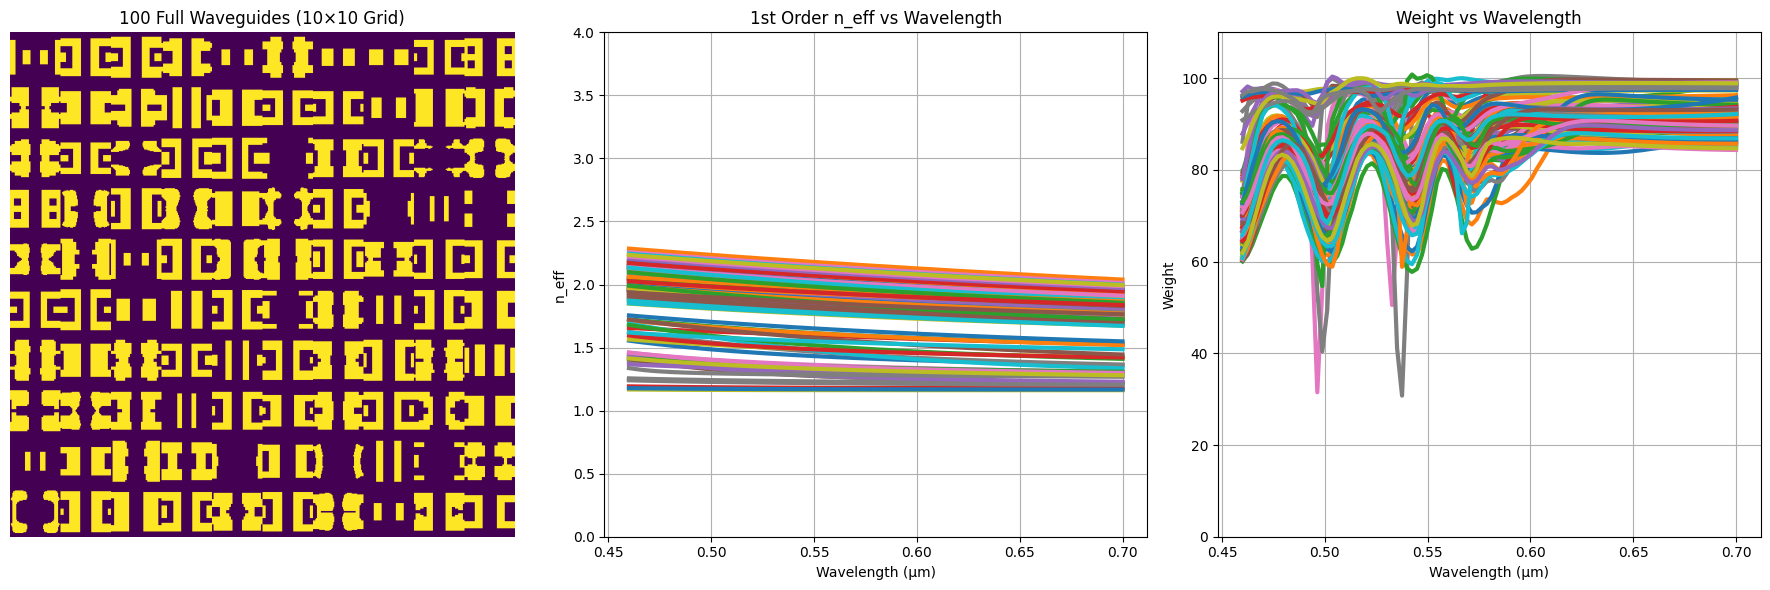

In [24]:
evaluate_100_samples(test_loader, model, device, fullwg_multi)

In [11]:
evaluate_100_samples(dataset, mode0_model, device, fullwg_multi)

AttributeError: 'NeffDataset' object has no attribute 'dataset'

torch.Size([8])
-1.1804146766662598
1.1260210275650024


/var/folders/4n/fq2wsfws1s5fqn5wt0ymgb7c0000gn/T/ipykernel_62778/2912386805.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wg_tensor = torch.tensor(wg, dtype=torch.float32)
/var/folders/4n/fq2wsfws1s5fqn5wt0ymgb7c0000gn/T/ipykernel_62778/2912386805.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  const_tail  = torch.tensor(params[1:], dtype=torch.float32).unsqueeze(0).to(device)        # [1,3]


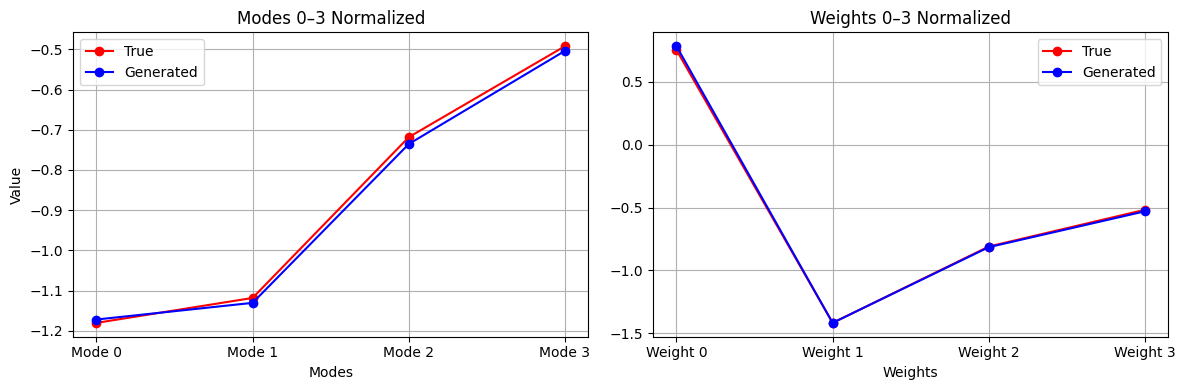

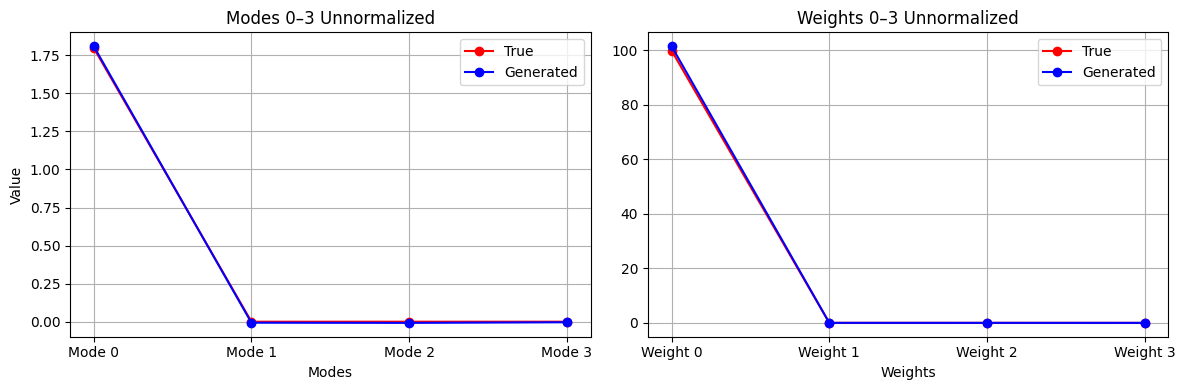

In [ ]:
wavelengths = np.array(np.linspace(-1.9, 1.5, 100))  
idx                   = random.randrange(len(dataset))
cond_vec, params, wg  = dataset[idx]           # params is shape (4,) with λ at index 0

denorm_real_cond = dataset.denormalize_cond(cond_vec)
denorm_real_param = dataset.denormalize_params(params)

print(cond_vec.size())
print(cond_vec[0].item())
print(params[0].item())

# freeze everything except wavelength
wg_tensor = torch.tensor(wg, dtype=torch.float32)
wg_np = wg.numpy()

if wg_tensor.ndim == 2:
    wg_tensor = wg_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, 32, 32]
elif wg_tensor.ndim == 3:
    wg_tensor = wg_tensor.unsqueeze(0)               # [1, 1, 32, 32]
wg_tensor = wg_tensor.to(device)
# print(params)
const_tail  = torch.tensor(params[1:], dtype=torch.float32).unsqueeze(0).to(device)        # [1,3]

# container for mode-0 vs wavelength
mode0_list = []
weight0_list = []
wavelength_list = []
all = []

eval_model.eval()
pt = params.unsqueeze(0)

with torch.no_grad():
    mode_pred = eval_model(wg_tensor, pt)

# plt.plot(cond_vec)
denorm_pred = dataset.denormalize_cond(mode_pred)

plot_modes_and_weights(cond_vec, mode_pred, 'Normalized')
plot_modes_and_weights(denorm_real_cond, denorm_pred, "Unnormalized")

with torch.no_grad():
    for lam in wavelengths:                                   # iterate over λ list
        lam_tensor = torch.tensor([[lam]], dtype=torch.float32).to(device)  # [1,1]
        params_tensor = torch.cat([lam_tensor, const_tail], dim=1)          # [1,4]
        params_norm = dataset.denormalize_params(params_tensor)
        mode_pred = dataset.denormalize_cond(eval_model(wg_tensor, params_tensor))     # shape [1,8] (modes+weights)
        mode0_list.append(mode_pred[0, 0].item())             # first index mode
        weight0_list.append(mode_pred[0,4].item())
        all.append(mode_pred)
        wavelength_list.append(params_norm[0,0].item())



# print(all[0].size())
# stacked = torch.cat(all, dim=0)  # shape [N, 8]

# # Plot each component (0 to 7) across the index of the list
# plt.figure(figsize=(15, 10))
# for i in range(8):
#     plt.axhline(denorm_real_cond[i], color='r')
#     plt.subplot(2, 4, i + 1)
#     plt.plot(wavelength_list,stacked[:, i].cpu().numpy())
#     plt.title(f"Index {i}")
#     plt.xlabel("Wavelength")
#     plt.ylabel(f"Value {i}")
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# mode0_list now holds mode-0 value for every λ in wavelengths
# print("λ (µm)  |  mode-0")
# for lam, m0 in zip(wavelength_list, mode0_list):
#     print(f"{lam:6.3f}  |  {m0:.6f}")


/tmp/ipykernel_514826/2933081429.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  waveguide_tensor = torch.tensor(wg, dtype=torch.float32)


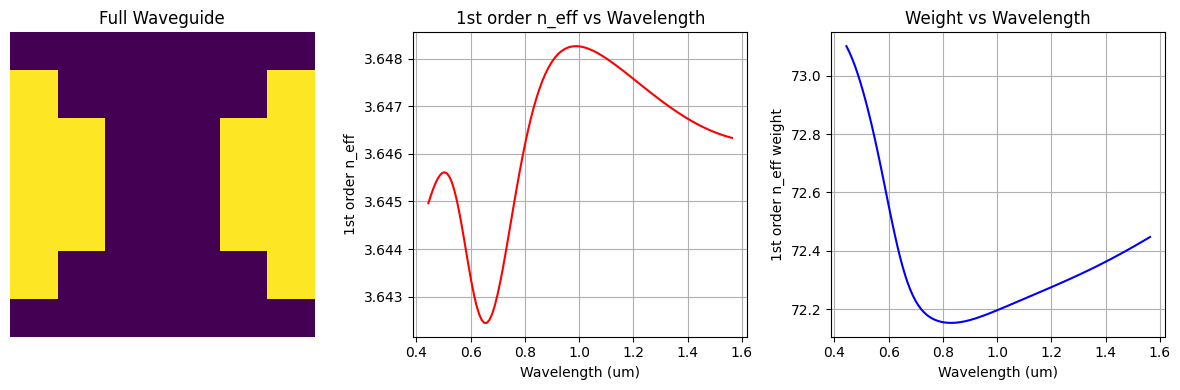

In [ ]:
import numpy as np

# Arrays of wavelength in meters and neff (same length)
# wavelengths = np.array(np.linspace(1.3e-6,1.6e-6,100))     # e.g., np.linspace(1.3e-6, 1.6e-6, 100)
wavelengths = np.array(wavelength_list)
neff = np.array(mode0_list)            # from your solver
omega = 2 * np.pi * 3e8 / wavelengths  # Angular frequency

beta = 2 * np.pi * neff / wavelengths

# Sort if not already sorted
# sorted_indices = np.argsort(omega)
# omega = omega[sorted_indices]
# beta = beta[sorted_indices]

# Numerical derivative dβ/dω
d_beta_d_omega = np.gradient(beta, omega)

# Group index
ng = 3e8 * d_beta_d_omega

# Plot
# import matplotlib.pyplot as plt
# plt.plot(wavelengths, mode0_list)
# plt.xlabel("Wavelength (um)")
# plt.ylabel("1st order n_eff")
# plt.title("1st order n_eff vs Wavelength")
# plt.grid(True)
# plt.show()

# plt.plot(wavelengths, weight0_list)
# plt.xlabel("Wavelength (um)")
# plt.ylabel("1st order n_eff weight")
# plt.title("Weight vs Wavelength")
# plt.grid(True)
# plt.show()
c


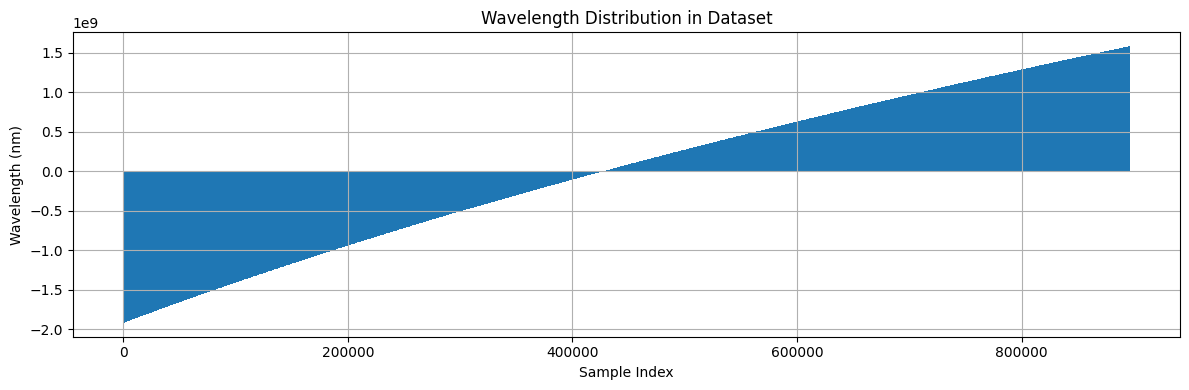

In [ ]:
wavelengths = [dataset[i][1][0] for i in range(len(dataset))]  # dataset[i][1] = params

# Convert to numpy for better handling
import numpy as np
wavelengths = np.array(wavelengths)

# Optional: sort for better visual structure
sorted_indices = np.argsort(wavelengths)
wavelengths_sorted = wavelengths[sorted_indices]

# Plot as bar chart
plt.figure(figsize=(12, 4))
plt.bar(range(len(wavelengths_sorted)), wavelengths_sorted * 1e9, width=1.0)
plt.xlabel("Sample Index")
plt.ylabel("Wavelength (nm)")
plt.title("Wavelength Distribution in Dataset")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(min(wavelengths_sorted))
print(max(wavelengths_sorted))

-1.9166535
1.5828345
